In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
df = pd.read_csv('Downloads/Diamonds Prices2022.csv.zip')

In [13]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [17]:
print('\nColumns:', list(df.columns))
print('\nInfo:')
print(df.info())
print('\nBasic Stats:')
print(df.describe(include='all').transpose())


Columns: ['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53943 non-null  int64  
 1   carat       53943 non-null  float64
 2   cut         53943 non-null  object 
 3   color       53943 non-null  object 
 4   clarity     53943 non-null  object 
 5   depth       53943 non-null  float64
 6   table       53943 non-null  float64
 7   price       53943 non-null  int64  
 8   x           53943 non-null  float64
 9   y           53943 non-null  float64
 10  z           53943 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB
None

Basic Stats:
              count unique    top   freq         mean           std    min  \
Unnamed: 0  53943.0    NaN    NaN    NaN      26972.0  15572.147122    1.0   
carat      

In [23]:
# Missing values, Duplicates checking
missing_val = df.isna().sum().sort_values(ascending=False)
print('Missing values per column:\n', missing_val)
dupl = df.duplicated().sum()
print('\nTotal duplicated rows:', dupl)


Missing values per column:
 Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Total duplicated rows: 0


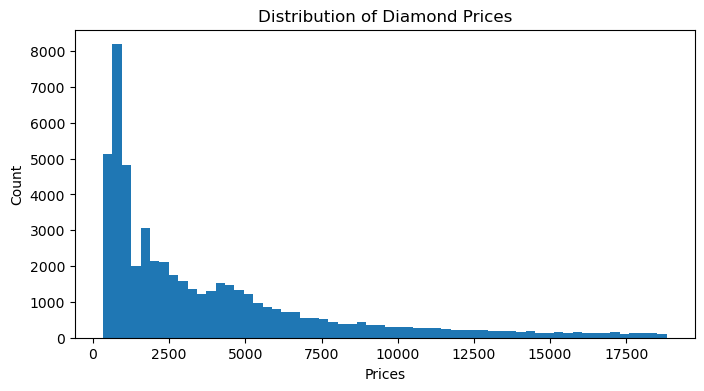

In [33]:
# Distribution of data prices.
plt.figure(figsize=(8,4))
plt.hist(df['price'], bins=60)
plt.title('Distribution of Diamond Prices')
plt.xlabel('Prices')
plt.ylabel('Count')
plt.show()

In [37]:
Target = 'price'
y = df[Target].values

categorical = [c for c in ['cut', 'color', 'clarity'] if c in df.columns]
numeric = [c for c in ['carat', 'depth', 'table', 'x','y','z'] if c in df.columns]
X = df[categorical + numeric].copy()

#Splitting of a test set(20%), then split remaining into train/val(80% --. 64//16)
X_temp, X_test, y_temp, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=42)

print('Train:',X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)
print('Categorical:', categorical)
print('Numeric:', numeric)


Train: (34523, 9) Val: (8631, 9) Test: (10789, 9)
Categorical: ['cut', 'color', 'clarity']
Numeric: ['carat', 'depth', 'table', 'x', 'y', 'z']


In [39]:
# Why OneHot? Tree models can handle categoricals via one-hot without scaling numerical features.
# We build a ColumnTransformer that applies OneHot to categoricals and passes numeric as-is.

pre_ml = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric),
    ]
)

In [45]:
linreg = Pipeline(steps=[
    ('prep', pre_ml),
    ('model', LinearRegression())
])
linreg.fit(X_train, y_train)

def eval_reg(y_true, y_pred, label=''):
    mae= mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'model': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

lin_val = eval_reg(y_val, linreg.predict(X_val), 'LinearRegression(val)')
lin_test = eval_reg(y_test, linreg.predict(X_test), 'LinearRegression(test)')

print(lin_val)
print(lin_test)

{'model': 'LinearRegression(val)', 'MAE': 744.6167955625073, 'RMSE': 1105.9694328511237, 'R2': 0.9254357706020888}
{'model': 'LinearRegression(test)', 'MAE': 736.7500868940588, 'RMSE': 1105.0194549384717, 'R2': 0.9217922841431757}


In [51]:
# Why RF? Nonlinear, robust to outliers, handles mixed features well, strong baseline for tabular data.
rf = Pipeline(steps=[
    ("prep", pre_ml),
    ("model", RandomForestRegressor(
        n_estimators=300,      # more trees -> better but slower
        max_depth=None,        # let trees grow; we'll trust OOB/val to catch overfit
        n_jobs=-1,
        random_state=42
    ))
])
        
rf.fit(X_train, y_train)

rf_val = eval_reg(y_val, rf.predict(X_val), 'RandomForest(val)')
rf_test = eval_reg(y_test, rf.predict(X_test), 'RandomForest(test)')

print(rf_val)
print(rf_test)

{'model': 'RandomForest(val)', 'MAE': 284.0697904351792, 'RMSE': 563.3599761022382, 'R2': 0.9806528827077634}
{'model': 'RandomForest(test)', 'MAE': 271.74092881074733, 'RMSE': 548.7881910488113, 'R2': 0.980710575591819}


In [59]:
# Neural networks are sensitive to feature scale. We'll:
# - OneHot encode categoricals
# - Standardize numeric features to mean=0, std=1
# Then we will feed the dense numerical feature matrix to Keras.

pre_nn = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
        ("num", StandardScaler(), numeric),
    ]
)

# Fit the transformer on train only, then transform splits to dense numpy arrays.
X_train_nn = pre_nn.fit_transform(X_train)
X_val_nn = pre_nn.transform(X_val)
X_test_nn = pre_nn.transform(X_test)

input_dim = X_train_nn.shape[1]
input_dim

26

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           6,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,129 (188.00 KB)

 Trainable params: 48,129 (188.00 KB)

 Non-trainable params: 0 (0.00 B)

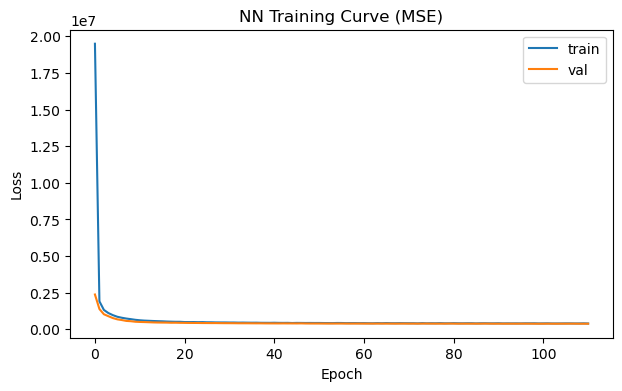

270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
{'model': 'NeuralNet (val)', 'MAE': 313.20937067641125, 'RMSE': 617.1795525946127, 'R2': 0.9767796993255615}
{'model': 'NeuralNet (test)', 'MAE': 311.76162743769515, 'RMSE': 1355.973569796726, 'R2': 0.8822360634803772}


In [61]:
# We'll use a small MLP with dropout. We monitor validation loss and early-stop to avoid overfitting.
tf.random.set_seed(42)

def build_mlp(dim):
    model = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.10),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)  # regression output
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae"),
                 keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    return model

mlp = build_mlp(input_dim)
mlp.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
]

history = mlp.fit(
    X_train_nn, y_train,
    validation_data=(X_val_nn, y_val),
    epochs=200,
    batch_size=256,
    verbose=0,
    callbacks=callbacks
)

# Plot training curves (loss)
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("NN Training Curve (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Evaluate
y_val_pred_nn = mlp.predict(X_val_nn).ravel()
y_test_pred_nn = mlp.predict(X_test_nn).ravel()

nn_val = eval_reg(y_val, y_val_pred_nn, "NeuralNet (val)")
nn_test = eval_reg(y_test, y_test_pred_nn, "NeuralNet (test)")

print(nn_val)
print(nn_test)

# Compare models

In [64]:
import pandas as pd
results = pd.DataFrame([lin_val, lin_test, rf_val, rf_test, nn_val, nn_test])
results

,model,MAE,RMSE,R2
0,LinearRegression(val),744.616796,1105.969433,0.925436
1,LinearRegression(test),736.750087,1105.019455,0.921792
2,RandomForest(val),284.069790,563.359976,0.980653
3,RandomForest(test),271.740929,548.788191,0.980711
4,NeuralNet (val),313.209371,617.179553,0.976780
5,NeuralNet (test),311.761627,1355.973570,0.882236


In [68]:
# We'll take one sample from X_test and show predictions from all models side by side,
# so you can narrate what the system does end-to-end.

i = 0
x_row = X_test.iloc[[i]]  # DataFrame with one row
true_price = float(y_test[i])

pred_lin = float(linreg.predict(x_row)[0])
pred_rf  = float(rf.predict(x_row)[0])
pred_nn  = float(mlp.predict(pre_nn.transform(x_row))[0])

print("Features:\n", x_row.to_dict(orient="records")[0])
print(f"True price: {true_price:,.2f}")
print(f"LinearRegression: {pred_lin:,.2f}")
print(f"RandomForest:     {pred_rf:,.2f}")
print(f"NeuralNet:        {pred_nn:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
Features:
 {'cut': 'Ideal', 'color': 'G', 'clarity': 'VVS1', 'carat': 0.24, 'depth': 62.1, 'table': 56.0, 'x': 3.97, 'y': 4.0, 'z': 2.47}
True price: 559.00
LinearRegression: 681.81
RandomForest:     566.52
NeuralNet:        555.15


C:\Users\Shiva\AppData\Local\Temp\ipykernel_22460\1665628413.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_nn  = float(mlp.predict(pre_nn.transform(x_row))[0])
